In [1]:
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import polars as pl

In [2]:
trace = az.from_netcdf("data/trace.nc")
# trace

In [3]:
# summary = az.summary(trace)
# summary[summary["r_hat"] > 1.01]

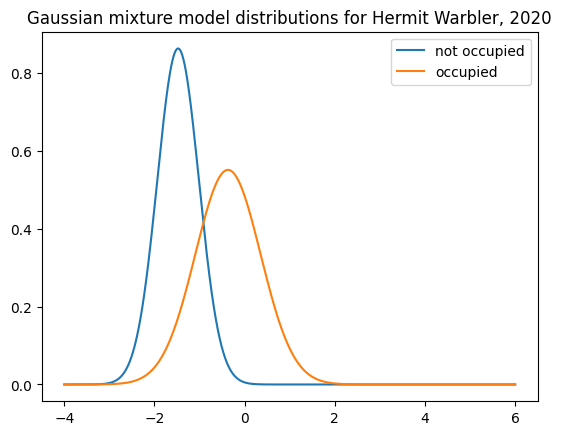

In [4]:
from scipy.stats import norm

mu0 = trace["posterior"].data_vars["mu"].to_numpy().reshape(-1, 2)[:, 0]
sigma0 = trace["posterior"].data_vars["sigma"].to_numpy().reshape(-1, 2)[:, 0]

mu1 = trace["posterior"].data_vars["mu"].to_numpy().reshape(-1, 2)[:, 1]
sigma1 = trace["posterior"].data_vars["sigma"].to_numpy().reshape(-1, 2)[1]


xs = np.linspace(-4, 6, 5000)
not_occ = norm.pdf(xs, mu0.mean(), sigma0.mean())
occ = norm.pdf(xs, mu1.mean(), sigma1.mean())

plt.plot(xs, not_occ, label="not occupied")
plt.plot(xs, occ, label="occupied")
plt.title("Gaussian mixture model distributions for Hermit Warbler, 2020")
plt.legend()
plt.show()


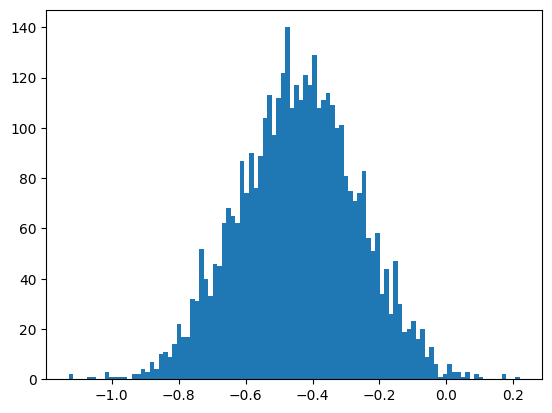

In [8]:
plt.hist(trace["posterior"].data_vars["alpha1"].to_numpy().flatten(), bins=100)
plt.show()